# E-Commerce Sales Forecasting

This project uses 36 months of historical sales data from an electronics company to forecast the next 6 months. The work includes monthly data preparation, outlier handling, stationarity testing, trend and seasonality decomposition, SARIMA and XGBoost model comparison using RMSE, and a final 6-month forecast with 95% prediction intervals.

## 1. Load and Prepare Monthly Sales Data

The original CSV contains individual sales transactions. We convert the transaction-level data into monthly total sales because the forecasting task requires a monthly time series.

In [1]:
import os
import json
import itertools
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

DATA_FILE = "data/ecommerce_sales_data.csv"
OUTPUT_DIR = "outputs"
MODEL_DIR = "models"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

df = pd.read_csv(DATA_FILE)

df["Order Date"] = pd.to_datetime(df["Order Date"])

monthly_sales = (
    df.set_index("Order Date")["Sales"]
    .resample("MS")
    .sum()
)

print("Number of months:", len(monthly_sales))
print("Start date:", monthly_sales.index.min().date())
print("End date:", monthly_sales.index.max().date())

Number of months: 36
Start date: 2022-01-01
End date: 2024-12-01


## 2. Handle Monthly Outliers

We use the IQR rule on the monthly sales totals. Unusual monthly values are clipped to the calculated limits so that extreme observations do not have too much influence on the models.

In [2]:
q1 = monthly_sales.quantile(0.25)
q3 = monthly_sales.quantile(0.75)
iqr = q3 - q1

lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

outlier_mask = (
    (monthly_sales < lower_limit)
    | (monthly_sales > upper_limit)
)

outliers_handled = int(outlier_mask.sum())

monthly_sales_clean = monthly_sales.clip(
    lower=lower_limit,
    upper=upper_limit
)

print("Monthly outliers detected:", outliers_handled)

Monthly outliers detected: 0


## 3. Check Stationarity and Decompose the Series

The Augmented Dickey-Fuller test checks whether the monthly sales series is stationary. We also decompose the series to examine its trend, seasonal pattern, and residual component.

ADF Statistic: -4.725263851845848
ADF p-value: 7.542210477895912e-05
The monthly sales series is stationary.


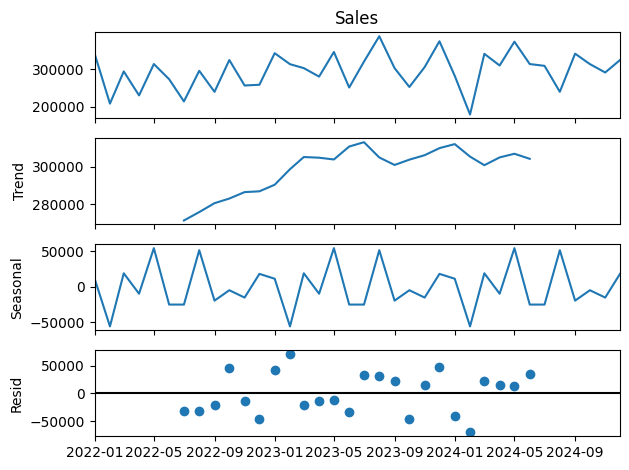

In [3]:
adf_result = adfuller(monthly_sales_clean)

adf_statistic = adf_result[0]
adf_pvalue = adf_result[1]

print("ADF Statistic:", adf_statistic)
print("ADF p-value:", adf_pvalue)

if adf_pvalue < 0.05:
    print("The monthly sales series is stationary.")
else:
    print("The monthly sales series is not stationary.")

decomposition = seasonal_decompose(
    monthly_sales_clean,
    model="additive",
    period=12
)

decomposition.plot()

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "decomposition.png"
    ),
    dpi=150
)

plt.show()
plt.close()

## 4. Split the Data for Model Validation

The first 30 months are used for training and the final 6 known months are used for validation. This allows the forecasting models to be compared before forecasting the future 6 months.

In [4]:
train_data = monthly_sales_clean.iloc[:30]
validation_data = monthly_sales_clean.iloc[30:]

print("Training months:", len(train_data))
print("Validation months:", len(validation_data))

Training months: 30
Validation months: 6


## 5. Tune SARIMA Models

Several SARIMA `(p,d,q)` combinations and seasonal configurations with a 12-month period are tested. RMSE on the validation period is used to select the best SARIMA configuration.

In [5]:
sarima_results = []

orders = list(
    itertools.product(
        [0, 1, 2],
        [0, 1],
        [0, 1, 2]
    )
)

seasonal_orders = [
    (0, 0, 0, 12),
    (1, 0, 0, 12),
    (0, 0, 1, 12),
    (1, 0, 1, 12),
    (0, 1, 0, 12),
    (1, 1, 0, 12),
    (0, 1, 1, 12),
    (1, 1, 1, 12)
]

for order in orders:
    for seasonal_order in seasonal_orders:

        try:
            model = SARIMAX(
                train_data,
                order=order,
                seasonal_order=seasonal_order,
                trend="c",
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            fitted_model = model.fit(disp=False)

            forecast = fitted_model.forecast(
                steps=len(validation_data)
            )

            rmse = np.sqrt(
                mean_squared_error(
                    validation_data,
                    forecast
                )
            )

            sarima_results.append({
                "order": order,
                "seasonal_order": seasonal_order,
                "rmse": float(rmse),
                "aic": float(fitted_model.aic)
            })

        except Exception:
            continue

sarima_results = sorted(
    sarima_results,
    key=lambda x: x["rmse"]
)

best_sarima = sarima_results[0]

sarima_rmse = best_sarima["rmse"]

print("Best SARIMA model:")
print("Order:", best_sarima["order"])
print("Seasonal order:", best_sarima["seasonal_order"])
print("Validation RMSE:", sarima_rmse)

Best SARIMA model:
Order: (2, 0, 2)
Seasonal order: (0, 0, 1, 12)
Validation RMSE: 30038.11395246995


## 6. Train XGBoost and Compare the Models

XGBoost is trained with lag features from the monthly sales series and the calendar month. Recursive forecasting is used for the validation period, and its RMSE is compared with SARIMA.

In [6]:
def create_xgb_features(series):

    features = pd.DataFrame(
        index=series.index
    )

    features["lag_1"] = series.shift(1)
    features["lag_2"] = series.shift(2)
    features["lag_3"] = series.shift(3)
    features["lag_6"] = series.shift(6)
    features["lag_12"] = series.shift(12)
    features["month"] = series.index.month

    return features


def train_xgb_and_forecast(history, future_dates):

    features = create_xgb_features(
        history
    ).dropna()

    X_train = features

    y_train = history.loc[
        features.index
    ]

    model = XGBRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    history_for_prediction = history.copy()

    predictions = []

    for date in future_dates:

        row = {
            "lag_1": history_for_prediction.iloc[-1],
            "lag_2": history_for_prediction.iloc[-2],
            "lag_3": history_for_prediction.iloc[-3],
            "lag_6": history_for_prediction.iloc[-6],
            "lag_12": history_for_prediction.iloc[-12],
            "month": date.month
        }

        row_df = pd.DataFrame(
            [row],
            index=[date]
        )

        prediction = float(
            model.predict(row_df)[0]
        )

        predictions.append(prediction)

        history_for_prediction.loc[
            date
        ] = prediction

    return np.array(predictions), model


xgb_validation_forecast, xgb_model = train_xgb_and_forecast(
    train_data,
    validation_data.index
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        validation_data,
        xgb_validation_forecast
    )
)

print("XGBoost validation RMSE:", xgb_rmse)

XGBoost validation RMSE: 51477.995128096874


## 7. Select the Model

The model with the lower validation RMSE is selected. The model choice and evaluation information are saved so that the final forecasting step can use the selected configuration.

In [7]:
if sarima_rmse <= xgb_rmse:

    selected_model = "SARIMA"

else:

    selected_model = "XGBoost"


model_choice = {
    "selected_model": selected_model,
    "sarima_order": list(best_sarima["order"]),
    "seasonal_order": list(best_sarima["seasonal_order"]),
    "sarima_rmse": float(sarima_rmse),
    "xgboost_rmse": float(xgb_rmse),
    "adf_statistic": float(adf_statistic),
    "adf_pvalue": float(adf_pvalue),
    "monthly_outliers_handled": outliers_handled
}

print("Selected model:", selected_model)

with open(
    os.path.join(
        MODEL_DIR,
        "model_choice.json"
    ),
    "w"
) as file:

    json.dump(
        model_choice,
        file,
        indent=4
    )

Selected model: SARIMA


## 8. Prepare the Next 6 Forecast Months

The historical data is used to create the six future monthly dates immediately after the last known month.

In [8]:
last_date = monthly_sales_clean.index[-1]

future_dates = pd.date_range(
    start=last_date + pd.offsets.MonthBegin(1),
    periods=6,
    freq="MS"
)

print("Forecast period:")
print(
    future_dates[0].date(),
    "to",
    future_dates[-1].date()
)

Forecast period:
2025-01-01 to 2025-06-01


## 9. Generate the 6-Month Forecast and 95% Prediction Interval

The selected model is retrained using all 36 months of cleaned data. SARIMA provides its confidence interval directly. For XGBoost, an approximate 95% prediction interval is created from the training residual standard deviation.

In [9]:
if selected_model == "SARIMA":

    order = tuple(
        model_choice["sarima_order"]
    )

    seasonal_order = tuple(
        model_choice["seasonal_order"]
    )

    model = SARIMAX(
        monthly_sales_clean,
        order=order,
        seasonal_order=seasonal_order,
        trend="c",
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted_model = model.fit(
        disp=False
    )

    forecast_result = fitted_model.get_forecast(
        steps=6
    )

    forecast_values = (
        forecast_result.predicted_mean
    )

    confidence_interval = (
        forecast_result.conf_int()
    )

    lower_bound = confidence_interval.iloc[:, 0]
    upper_bound = confidence_interval.iloc[:, 1]

    lower_bound = lower_bound.clip(
        lower=0
    )

    forecast_values = forecast_values.clip(
        lower=0
    )

    upper_bound = upper_bound.clip(
        lower=0
    )

else:

    features = create_xgb_features(
        monthly_sales_clean
    ).dropna()

    X_train = features

    y_train = monthly_sales_clean.loc[
        features.index
    ]

    xgb_model = XGBRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    )

    xgb_model.fit(
        X_train,
        y_train
    )

    history = monthly_sales_clean.copy()

    predictions = []

    for date in future_dates:

        row = {
            "lag_1": history.iloc[-1],
            "lag_2": history.iloc[-2],
            "lag_3": history.iloc[-3],
            "lag_6": history.iloc[-6],
            "lag_12": history.iloc[-12],
            "month": date.month
        }

        row_df = pd.DataFrame(
            [row],
            index=[date]
        )

        prediction = float(
            xgb_model.predict(row_df)[0]
        )

        prediction = max(
            0,
            prediction
        )

        predictions.append(
            prediction
        )

        history.loc[
            date
        ] = prediction

    forecast_values = pd.Series(
        predictions,
        index=future_dates
    )

    training_prediction = (
        xgb_model.predict(X_train)
    )

    residuals = (
        y_train.values
        - training_prediction
    )

    residual_std = np.std(
        residuals,
        ddof=1
    )

    margin = 1.96 * residual_std

    lower_bound = (
        forecast_values - margin
    ).clip(lower=0)

    upper_bound = (
        forecast_values + margin
    ).clip(lower=0)


forecast_table = pd.DataFrame({
    "Month": future_dates,
    "Forecast Sales": forecast_values.values,
    "Lower 95%": lower_bound.values,
    "Upper 95%": upper_bound.values
})

print(forecast_table)

       Month  Forecast Sales      Lower 95%      Upper 95%
0 2025-01-01   301827.456196  216894.413056  386760.499336
1 2025-02-01   299933.712038  205567.345104  394300.078973
2 2025-03-01   305632.646824  204285.988521  406979.305128
3 2025-04-01   308559.219187  207203.851090  409914.587284
4 2025-05-01   308419.064636  205889.084694  410949.044579
5 2025-06-01   306486.094714  203590.133694  409382.055733


## 10. Save and Display Forecast Results

The six forecast months and their prediction intervals are saved as a CSV file and displayed below.

In [10]:
forecast_table.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "forecast.csv"
    ),
    index=False
)

print("Saved: outputs/forecast.csv")

forecast_table

Saved: outputs/forecast.csv


,Month,Forecast Sales,Lower 95%,Upper 95%
0,2025-01-01,301827.456196,216894.413056,386760.499336
1,2025-02-01,299933.712038,205567.345104,394300.078973
2,2025-03-01,305632.646824,204285.988521,406979.305128
3,2025-04-01,308559.219187,207203.851090,409914.587284
4,2025-05-01,308419.064636,205889.084694,410949.044579
5,2025-06-01,306486.094714,203590.133694,409382.055733


## 11. Visualize the Forecast

The historical monthly sales, six-month forecast, and 95% prediction interval are plotted together and saved as an image.

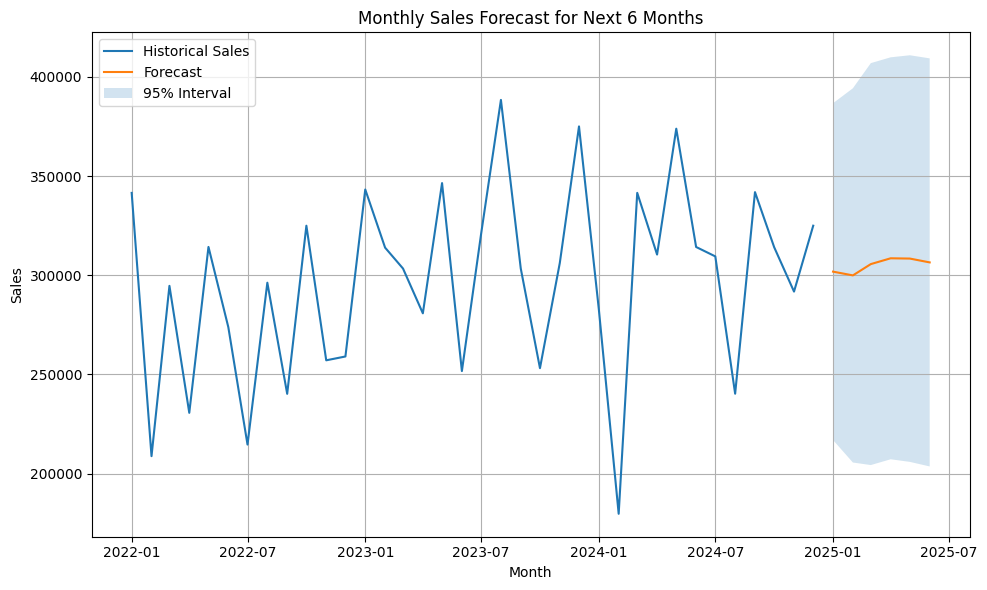

Saved: outputs/forecast.png


In [11]:
plt.figure(figsize=(10, 6))

plt.plot(
    monthly_sales_clean.index,
    monthly_sales_clean.values,
    label="Historical Sales"
)

plt.plot(
    future_dates,
    forecast_values.values,
    label="Forecast"
)

plt.fill_between(
    future_dates,
    lower_bound.values,
    upper_bound.values,
    alpha=0.2,
    label="95% Interval"
)

plt.xlabel("Month")
plt.ylabel("Sales")
plt.title(
    "Monthly Sales Forecast for Next 6 Months"
)

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "forecast.png"
    ),
    dpi=150
)

plt.show()

plt.close()

print("Saved: outputs/forecast.png")